[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv12 Object Detection on a Custom Dataset

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolov12-object-detection-model.ipynb)
[![arXiv](https://img.shields.io/badge/arXiv-2502.12524-b31b1b.svg)](https://arxiv.org/abs/2502.12524)
[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/train-yolov12-model)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/sunsmarterjie/yolov12)

[YOLOv12](https://github.com/sunsmarterjie/yolov12) is a newly proposed attention-centric variant of the YOLO family that focuses on incorporating efficient attention mechanisms into the backbone while preserving real-time performance. Instead of relying heavily on CNN-based architectures like its predecessors, YOLOv12 introduces a simple yet powerful “area attention” module, which strategically partitions the feature map to reduce the quadratic complexity of full self-attention. It also adopts residual efficient layer aggregation networks (R-ELAN) to enhance feature aggregation and training stability, especially for larger models. These innovations, together with refinements such as scaled residual connections and a reduced MLP ratio, enable YOLOv12 to harness the benefits of attention (e.g., better global context modeling) without sacrificing speed.

![yolov12-area-attention](https://media.roboflow.com/notebooks/examples/yolov12-area-attention.png)

Compared to prior YOLO iterations (e.g., YOLOv10, YOLOv11, and YOLOv8), YOLOv12 achieves higher detection accuracy with competitive or faster inference times across all model scales. Its five sizes—N, S, M, L, and X—range from 2.6M to 59.1M parameters, striking a strong accuracy–speed balance. For instance, the smallest YOLOv12-N surpasses other “nano” models by over 1% mAP with latency around 1.6 ms on a T4 GPU, and the largest YOLOv12-X achieves 55.2% mAP, comfortably outscoring comparable real-time detectors such as RT-DETR and YOLOv11-X . By matching or exceeding state-of-the-art accuracy while remaining fast, YOLOv12 represents a notable step forward for attention-based real-time object detection.

![yolov12-metrics](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov12-metrics.png)

## Environment setup

### Configure your API keys

To fine-tune YOLOv12, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [2]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [3]:
!nvidia-smi

Mon Nov 24 06:16:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies

**NOTE:** Currently, YOLOv12 does not have its own PyPI package, so we install it directly from GitHub while also adding roboflow (to conveniently pull datasets from the Roboflow Universe), supervision (to visualize inference results and benchmark the model’s performance), and flash-attn (to accelerate attention-based computations via optimized CUDA kernels).

In [ ]:
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn

### Download example data

Let's download an image we can use for YOLOv12 inference. Feel free to drag and drop your own images into the Files tab on the left-hand side of Google Colab, then reference their filenames in your code for a custom inference demo.

In [5]:
!wget https://media.roboflow.com/notebooks/examples/dog.jpeg

--2025-11-24 06:16:06--  https://media.roboflow.com/notebooks/examples/dog.jpeg
Resolving media.roboflow.com (media.roboflow.com)... 34.110.133.209
Connecting to media.roboflow.com (media.roboflow.com)|34.110.133.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106055 (104K) [image/jpeg]
Saving to: ‘dog.jpeg.1’

dog.jpeg.1          100%[===================>] 103.57K  --.-KB/s    in 0.001s  

2025-11-24 06:16:06 (122 MB/s) - ‘dog.jpeg.1’ saved [106055/106055]



## Run inference

In the example, we're using the `yolov12l.pt` model, but you can experiment with different model sizes by simply swapping out the model name during initialization. Options include `yolov12n.pt`, `yolov12s.pt`, `yolov12m.pt`, `yolov12l.pt`, and `yolov12x.pt`.

100%|██████████| 5.26M/5.26M [00:00<00:00, 357MB/s]


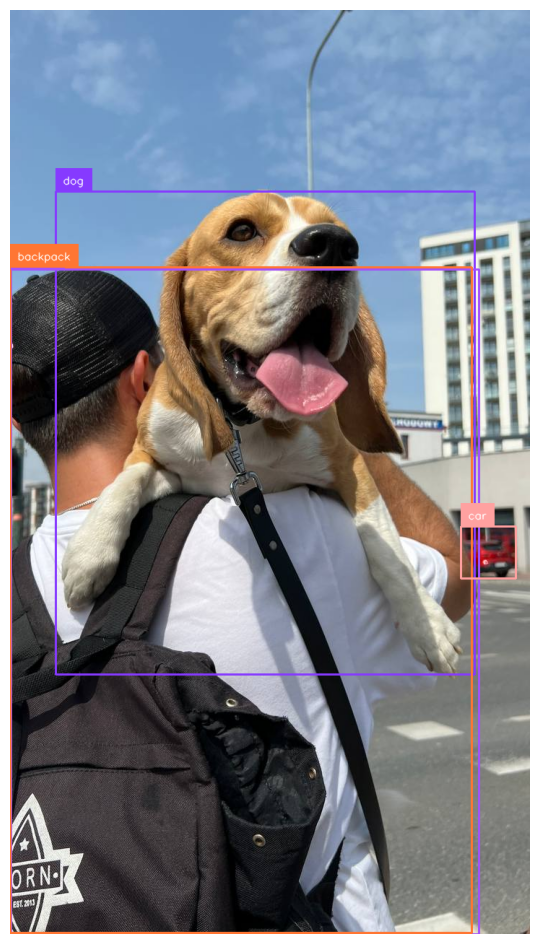

In [7]:
import cv2
from ultralytics import YOLO
import supervision as sv


image_path = f"{HOME}/dog.jpeg"
image = cv2.imread(image_path)

model = YOLO('yolov12n.pt')

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

## Download dataset from Roboflow Universe

In [27]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="R0Kn3RsXwmTLfyl1Mx7K")
project = rf.workspace("ringmabell").project("urp2025-simulation-hmtue")
version = project.version(1)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...


In [28]:
from roboflow import download_dataset

dataset = download_dataset('https://universe.roboflow.com/roboflow-100/urp2025(simulation)/dataset/1', 'yolov12')


loading Roboflow workspace...
loading Roboflow project...


RoboflowError: {
    "error": {
        "message": "Unsupported request. `GET /roboflow-100/urp2025(simulation)` does not exist or cannot be loaded due to missing permissions.",
        "type": "GraphMethodException",
        "hint": "You can see your active workspace by issuing a GET request to `/` with your `api_key`."
    }
}

In [33]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="R0Kn3RsXwmTLfyl1Mx7K")
project = rf.workspace("ringmabell").project("urp2025-simulation-hmtue")
version = project.version(2)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to urp2025(simulation)-2 in yolov12:: 100%|██████████| 456/456 [00:00<00:00, 8974.80it/s]


In [34]:
!ls {dataset.location}

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `ls /content/urp2025(simulation)-2'


**NOTE:** We need to make a few changes to our downloaded dataset so it will work with YOLOv12. Run the following bash commands to prepare your dataset for training by updating the relative paths in the `data.yaml` file, ensuring it correctly points to the subdirectories for your dataset's `train`, `test`, and `valid` subsets.

In [35]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `sed -i '$d' /content/urp2025(simulation)-2/data.yaml'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `sed -i '$d' /content/urp2025(simulation)-2/data.yaml'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `sed -i '$d' /content/urp2025(simulation)-2/data.yaml'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `sed -i '$d' /content/urp2025(simulation)-2/data.yaml'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> /content/urp2025(simulation)-2/data.yaml'


In [36]:
!cat {dataset.location}/data.yaml

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `cat /content/urp2025(simulation)-2/data.yaml'


## Fine-tune YOLOv12 model

We are now ready to fine-tune our YOLOv12 model. In the code below, we initialize the model using a starting checkpoint—here, we use `yolov12s.yaml`, but you can replace it with any other model (e.g., `yolov12n.pt`, `yolov12m.pt`, `yolov12l.pt`, or `yolov12x.pt`) based on your preference. We set the training to run for 100 epochs in this example; however, you should adjust the number of epochs along with other hyperparameters such as batch size, image size, and augmentation settings (scale, mosaic, mixup, and copy-paste) based on your hardware capabilities and dataset size.

**Note:** **Note that after training, you might encounter a `TypeError: argument of type 'PosixPath' is not iterable error` — this is a known issue, but your model weights will still be saved, so you can safely proceed to running inference.**

In [37]:
from ultralytics import YOLO

model = YOLO('yolov12n.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

New https://pypi.org/project/ultralytics/8.3.231 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.yaml, data=/content/urp2025(simulation)-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show

train: Scanning /content/urp2025(simulation)-2/train/labels... 187 images, 131 backgrounds, 0 corrupt: 100%|██████████| 187/187 [00:00<00:00, 2784.67it/s]

train: New cache created: /content/urp2025(simulation)-2/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/urp2025(simulation)-2/valid/labels... 25 images, 19 backgrounds, 0 corrupt: 100%|██████████| 25/25 [00:00<00:00, 1142.74it/s]

val: New cache created: /content/urp2025(simulation)-2/valid/labels.cache


...

                   all         25         14          1      0.921      0.928       0.81

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    100/100      3.62G      1.022     0.9609      1.569         12        640: 100%|██████████| 12/12 [00:04<00:00,  2.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.04it/s]


                   all         25         14          1      0.925      0.942      0.826

100 epochs completed in 0.159 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 5.4MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 376 layers, 2,508,539 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.26it/s]


                   all         25         14          1      0.925      0.942      0.811
Speed: 0.2ms preprocess, 4.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train3


## Evaluate fine-tuned YOLOv12 model

In [38]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1763965030.8e84da812998.4338.0  train_batch2.jpg
F1_curve.png					    train_batch540.jpg
labels_correlogram.jpg				    train_batch541.jpg
labels.jpg					    train_batch542.jpg
P_curve.png					    val_batch0_labels.jpg
PR_curve.png					    val_batch0_pred.jpg
R_curve.png					    weights
results.csv


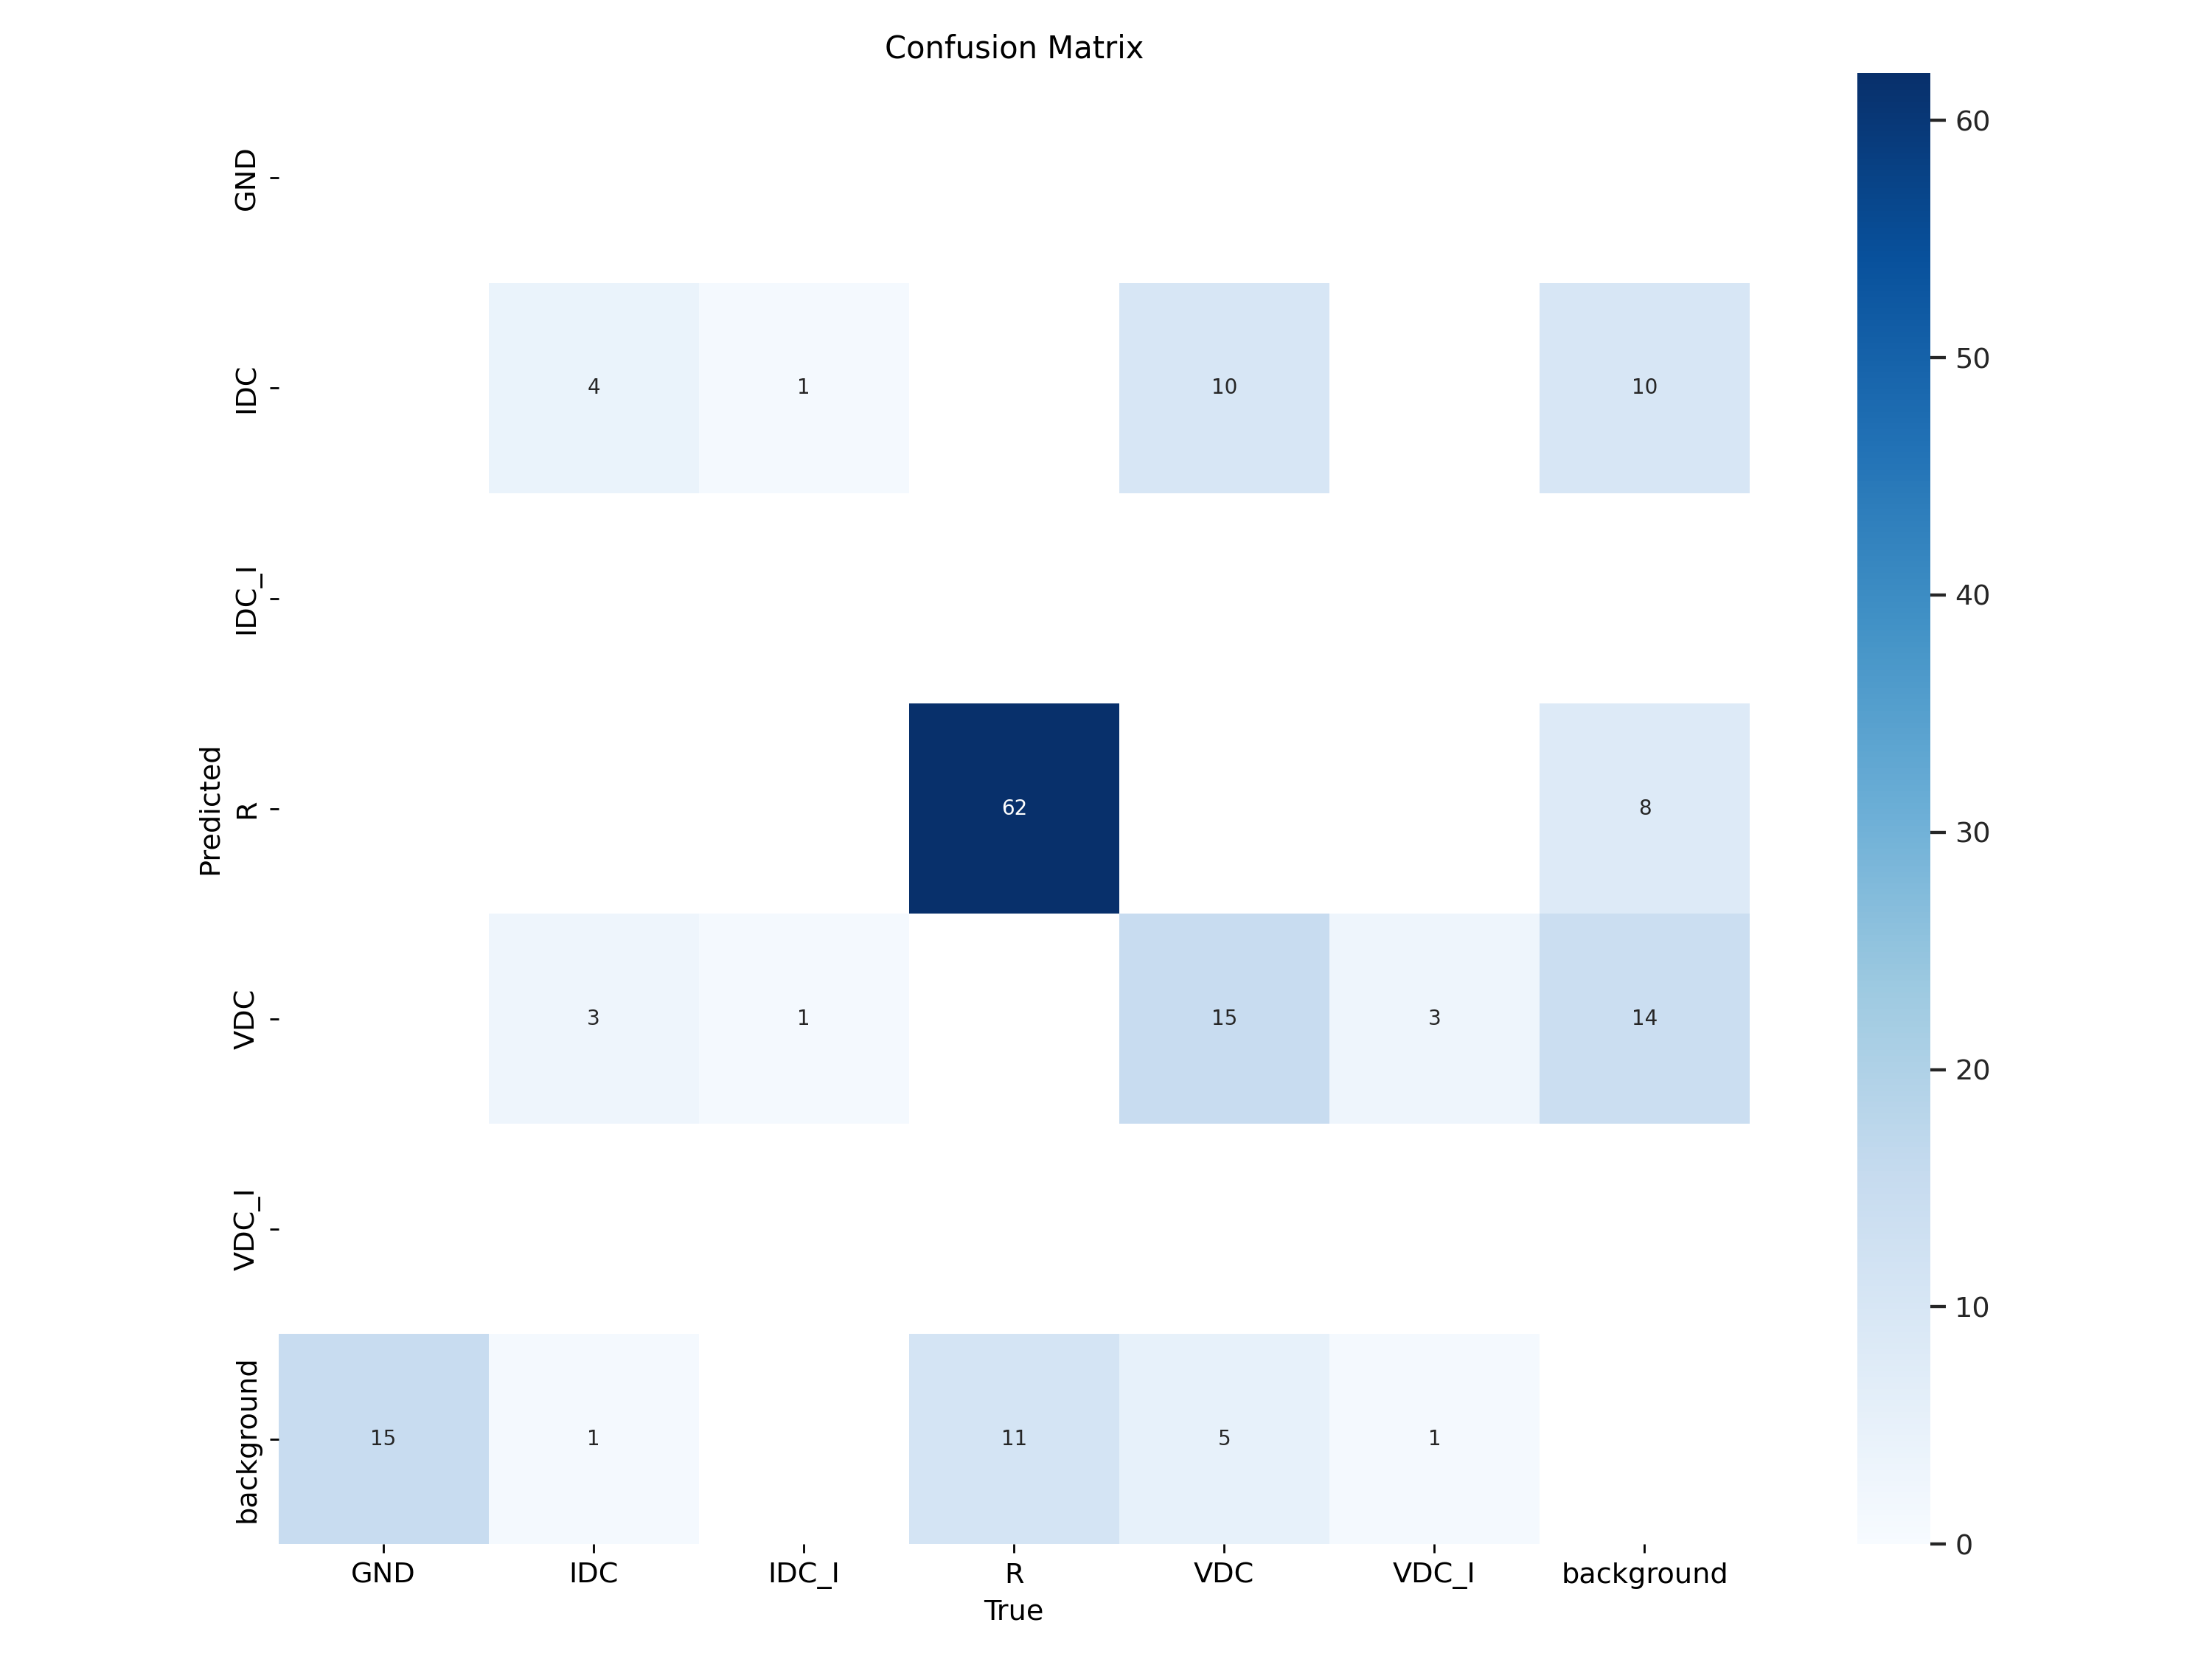

In [52]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

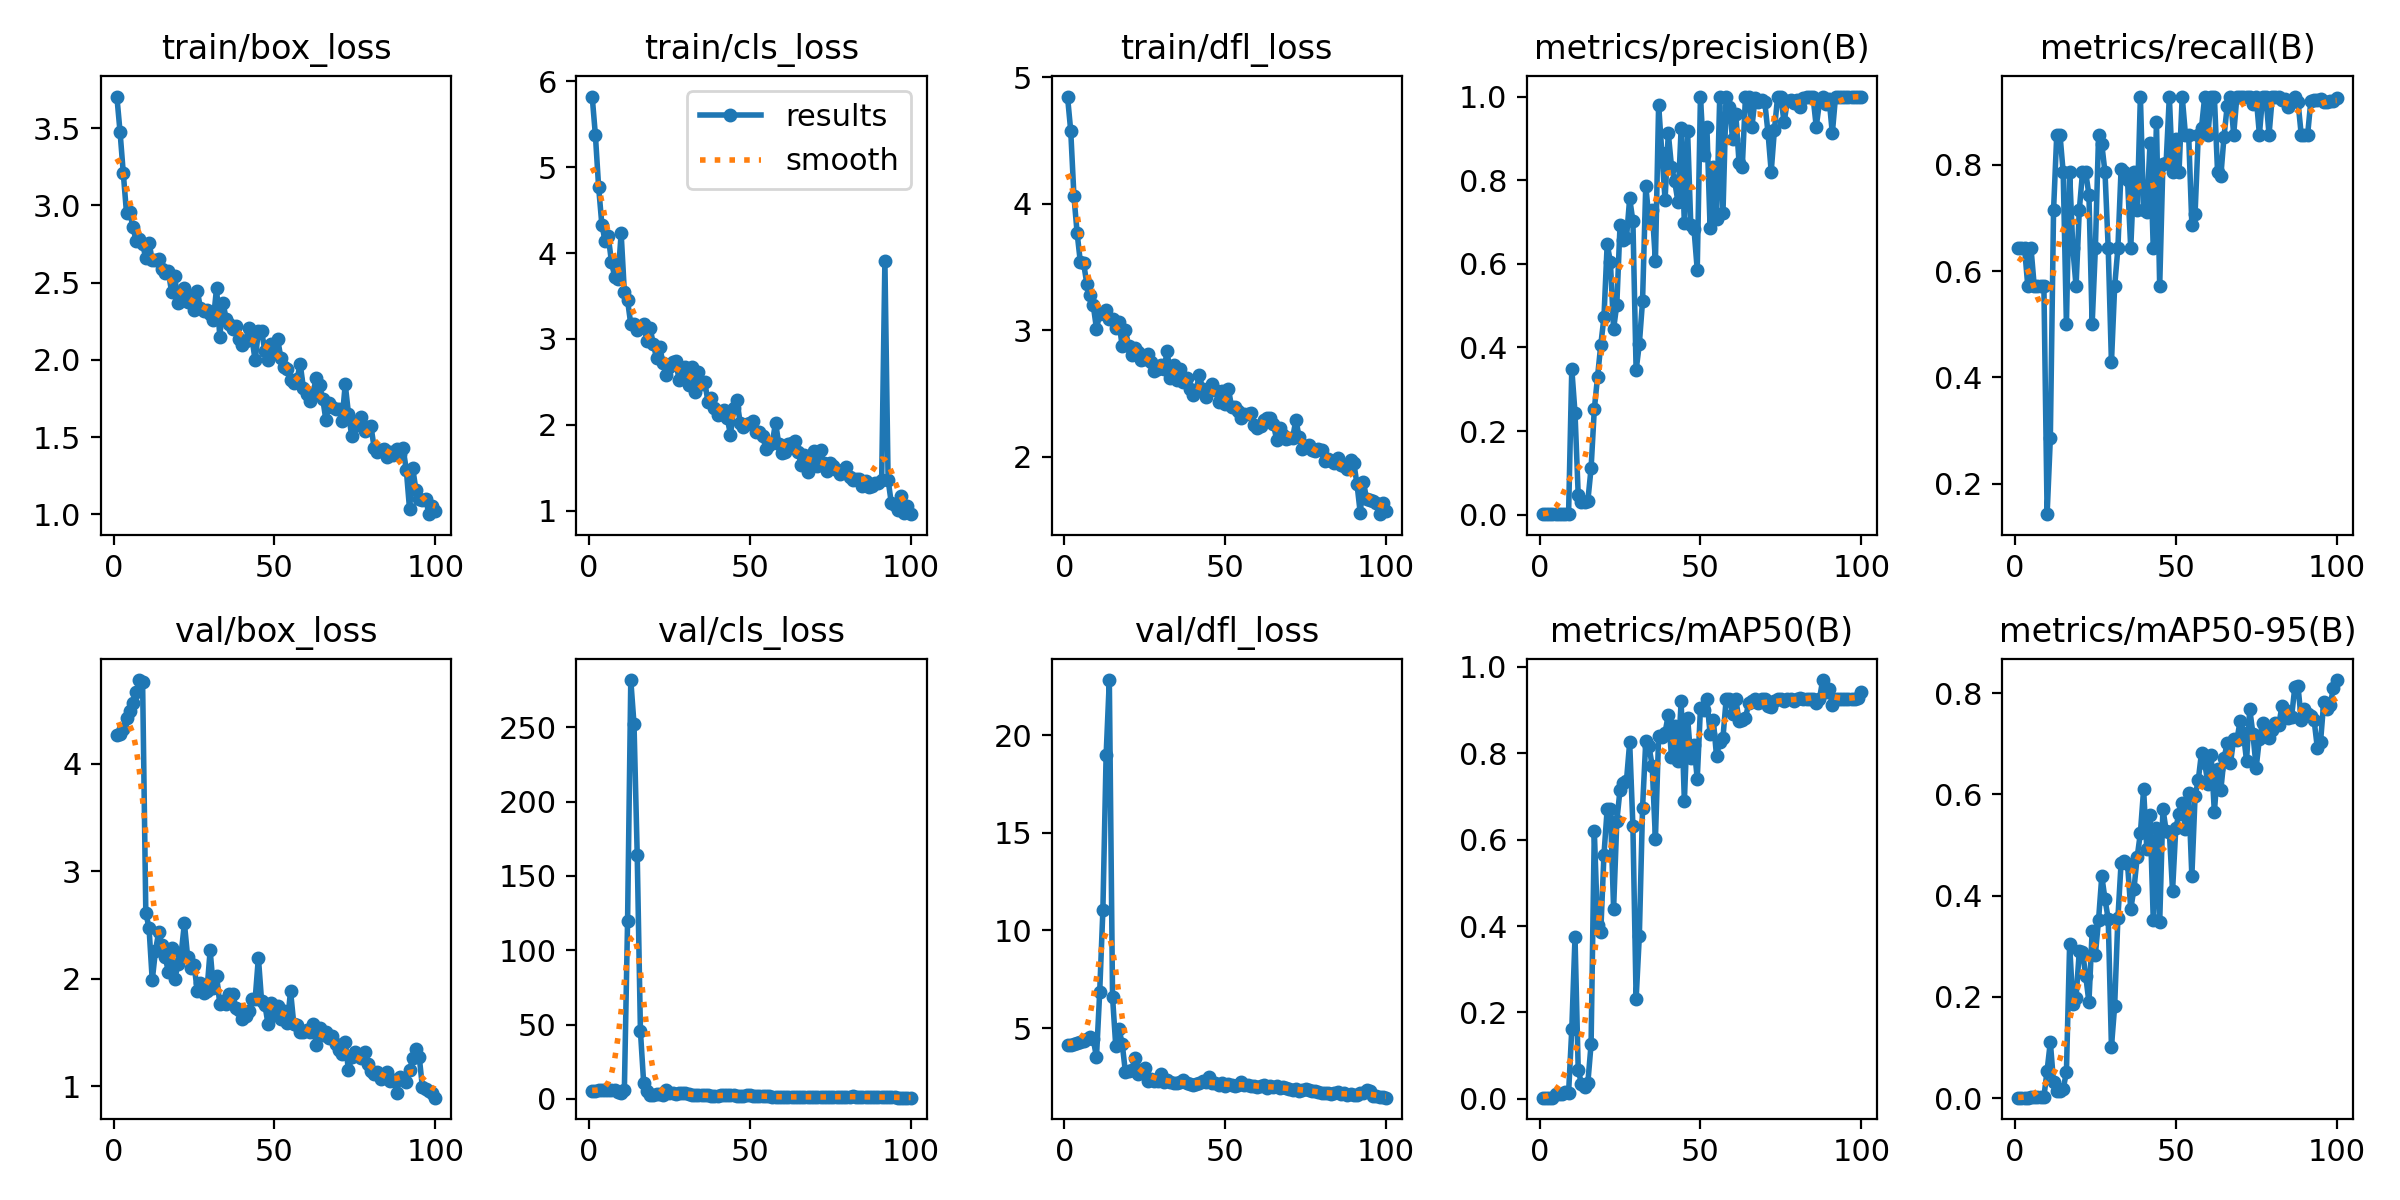

In [53]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train3/results.png', width=1000)

In [42]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

ds.classes

['cylinder']

In [54]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/{HOME}/runs/detect/train3/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [55]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.7113531353135313
mAP 50 0.8316831683168316
mAP 75 0.8316831683168316


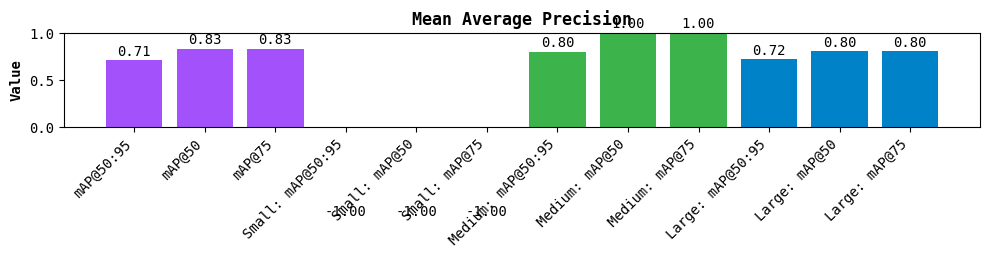

In [56]:
map.plot()

## Run inference with fine-tuned YOLOv12 model

In [57]:
import supervision as sv

model = YOLO(f'/{HOME}/runs/detect/train3/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

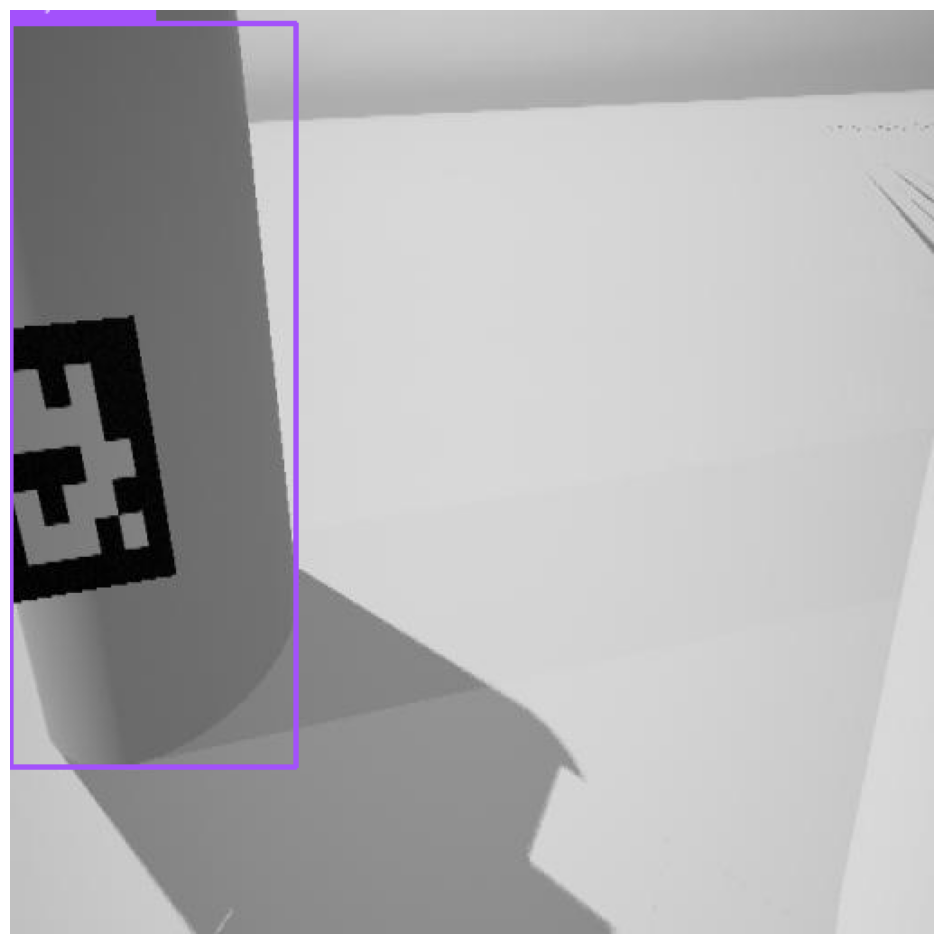

In [59]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

In [64]:
!pip install onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 14.9 MB/s eta 0:00:00


In [88]:
import torch

# 1. Load the PyTorch model using torch.hub.load
# NOTE: Replace 'ultralytics/yolov5' or 'ultralytics/yolov8'
# with the actual repository that your model architecture is based on.
# The 'custom' flag tells it to load local weights.
try:
    model = torch.hub.load(
        'ultralytics/yolov12',  # Repository path (use 'ultralytics/yolov8' if applicable)
        'custom',              # Model type (use 'custom' for local .pt file)
        path='yolov12n.pt',    # Path to your local weights file
        source='github'        # Specify source as GitHub
    )
except Exception as e:
    print(f"Failed to load via torch.hub.load: {e}")
    # If Hub fails, a more direct (but more complex) way is to instantiate the model class
    # and load state_dict, but that requires the model definition files.

model.eval()

# 2. Define a dummy input for tracing
img_size = (640, 640) # Standard YOLO input size
im = torch.zeros(1, 3, *img_size) # Device inference is handled by hub load usually

# 3. Export to ONNX (The rest remains the same)
weights = '/content/runs/detect/train3/weights/best.pt'
f = weights.replace('.pt', '.onnx') # yolov12n.onnx
torch.onnx.export(
    model,
    im,
    f,
    verbose=False,
    opset_version=17,
    input_names=['images'],
    output_names=['output'],
    dynamic_axes={'images': {0: 'batch', 2: 'height', 3: 'width'},
                  'output': {0: 'batch', 1: 'n_candidates'}}
)
print(f"ONNX model saved to {f}")

W1124 07:57:30.082000 4338 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Failed to load via torch.hub.load: 'Authorization'


TorchExportError: Failed to export the model with torch.export. [96mThis is step 1/3[0m of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytorch.org/docs/stable/generated/exportdb/index.html for more information.
- Debug `torch.export.export` and submit a PR to PyTorch.
- Create an issue in the PyTorch GitHub repository against the [96m*torch.export*[0m component and attach the full error stack as well as reproduction scripts.

## Exception summary

<class 'torch._dynamo.exc.UserError'>: Detected mismatch between the structure of `inputs` and `dynamic_shapes`: `inputs[0]` is a <class 'tuple'>, but `dynamic_shapes[0]` is a <class 'dict'>
For more information about this error, see: https://pytorch.org/docs/main/generated/exportdb/index.html#dynamic-shapes-validation

The error above occurred when calling torch.export.export. If you would like to view some more information about this error, and get a list of all

In [1]:
from models.common import DetectMultiBackend

weights = 'yolov12n.pt'
model = DetectMultiBackend(weights, device=torch.device('cpu'), dnn=False)
model.eval()

# 2. Define a dummy input for tracing
img_size = (640, 640)
# Ensure the dummy input is passed as a TUPLE or LIST of inputs to ONNX export
im = torch.zeros(1, 3, *img_size)
# Wrap the input tensor in a tuple/list if the model expects one input:
dummy_input = (im,)

ModuleNotFoundError: No module named 'models'